In [6]:
# Cell 1 — CONFIG (auto-detect project root above notebooks/)
from pathlib import Path
import pandas as pd
import numpy as np
import json

# 1) Start from the current notebook folder
_here = Path.cwd().resolve()

# 2) Walk upwards until we find a folder that contains data/runs/ca
def find_project_root(start: Path) -> Path:
    p = start
    for _ in range(6):  # go up at most 6 levels, adjust if your structure is deeper
        candidate = p / "data" / "runs" / "ca"
        if candidate.exists():
            return p
        p = p.parent
    raise RuntimeError(
        f"Could not locate 'data/runs/ca' starting from {_here}. "
        f"Please set PROJECT_ROOT manually (e.g., Path(r'...\\Project'))"
    )

PROJECT_ROOT = find_project_root(_here)
RUNS = PROJECT_ROOT / "data" / "runs" / "ca"

print("Notebook CWD: ", _here)
print("Detected PROJECT_ROOT: ", PROJECT_ROOT)
print("Using RUNS: ", RUNS)

# === EXACT folders from your console logs (2025-10-13) ===
FOLDERS = {
    # Phase 0 (Baseline)
    "Baseline": "baseline_20251013-180746",

    # Phase 1 (Micro)
    "M1: Async": "micro_async_async_20251013-180820",
    "M2: Refractory": "refractory_20251013-181238",
    "M3: Misclass (η=0.02)": "misclass_20251013-181314",
    "M1+M2": "async_refractory_async_refractory_20251013-181343",
    "M1+M3": "async_misclass_async_misclass_20251013-181747",
    "M2+M3": "refractory_misclass_20251013-182234",
    "M1+M2+M3": "async_refractory_misclass_async_refractory_misclass_20251013-182326",

    # Phase 2 (Macro)
    "M4: Hetero": "hetero_20251013-182737",
    "M5: Spatial": "spatial_20251013-182807",
    "M4: Hetero M5: Spatial": "hetero_spatial_20251013-182836",

    # Phase 3 (Micro + Macro ALL)
    "M1 M2 M3 M4 M5": "async_refractory_misclass_hetero_spatial_async_refractory_misclass_hetero_spatial_20251013-182903",
}

# Safety check — all mapped folders must exist under RUNS
missing = [name for name in FOLDERS.values() if not (RUNS / name).exists()]
if missing:
    # Print a quick directory listing to help debug
    print("\nFolders actually present under RUNS:")
    for d in sorted([p.name for p in RUNS.iterdir() if p.is_dir()]):
        print("  -", d)
    raise AssertionError(
        f"\nThese mapped folders do not exist under {RUNS}:\n{missing}\n"
        f"Double-check timestamps/labels or adjust FOLDERS."
    )

print("✔ Folder map OK — all specified batch directories exist.")


Notebook CWD:  C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\notebooks
Detected PROJECT_ROOT:  C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project
Using RUNS:  C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\runs\ca
✔ Folder map OK — all specified batch directories exist.


In [7]:
# Cell 2 — LOAD + SUMMARISE (Option 1 exact-folder mode)
# This version *only* reads from the exact batch folder specified in Cell 1's FOLDERS map.
# It does NOT scan by prefix/contains, so it cannot pull the wrong runs.

from pathlib import Path
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except Exception:
    HAS_ADJUSTTEXT = False

# ---- expect RUNS and FOLDERS from Cell 1 ----
# RUNS: Path to .../data/runs/ca
# FOLDERS: dict mapping "Condition" -> exact batch folder name (string)


# ---------- helpers ----------
def _num_to_pct(x):
    """Coerce '82.12%', 0.8212, or 82.12 to a % float in [0,100]."""
    if x is None:
        return None
    if isinstance(x, (int, float, np.integer, np.floating)):
        v = float(x)
    else:
        s = str(x).strip()
        if s.endswith("%"):
            try:
                v = float(s[:-1])
            except:
                return None
        else:
            try:
                v = float(s)
            except:
                return None
    if 0.0 <= v <= 1.0:
        v *= 100.0
    return v


def _try_extract_reach_from_json(js):
    """Try multiple key variants to find reachF / reachR inside a JSON object."""
    candF = ["reachF","reach_f","fake_reach","reach_fake","ReachF","Reach_F"]
    candR = ["reachR","reach_r","real_reach","reach_real","ReachR","Reach_R"]
    rF = rR = None
    for k in candF:
        if k in js:
            rF = _num_to_pct(js[k]); break
    for k in candR:
        if k in js:
            rR = _num_to_pct(js[k]); break
    return rF, rR


def _load_summary_csv(batch_dir: Path) -> pd.DataFrame:
    csv_path = batch_dir / "summary.csv"
    if not csv_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(csv_path)
    # normalise reach columns to percentages
    for col in ("reachF","reachR"):
        if col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].astype(str).str.replace("%","", regex=False)
            df[col] = pd.to_numeric(df[col], errors="coerce")
            if pd.notna(df[col].max()) and df[col].max() <= 1.0:
                df[col] = df[col] * 100.0
    return df


def _load_per_run_json_rows(batch_dir: Path) -> pd.DataFrame:
    rows = []
    for jp in batch_dir.glob("CA_run_*.json"):
        try:
            with open(jp, "r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception:
            continue

        def _row_from(d: dict):
            row = {}
            rF, rR = _try_extract_reach_from_json(d)
            row["reachF"], row["reachR"] = rF, rR
            for k, aliases in {
                "peak_f":   ["peak_f","peakF","peak_fake","fake_peak"],
                "peak_r":   ["peak_r","peakR","peak_real","real_peak"],
                "t_peak_f": ["t_peak_f","tpeak_f","time_to_peak_f","tPeakF"],
                "t_peak_r": ["t_peak_r","tpeak_r","time_to_peak_r","tPeakR"],
            }.items():
                for a in aliases:
                    if a in d:
                        row[k] = d[a]; break
            return row

        if isinstance(data, dict):
            row = _row_from(data)
            if any(v is not None for v in row.values()):
                rows.append(row)
        elif isinstance(data, list):
            for it in data:
                if isinstance(it, dict):
                    row = _row_from(it)
                    if any(v is not None for v in row.values()):
                        rows.append(row)

    if rows:
        df = pd.DataFrame(rows)
        for col in ("reachF","reachR"):
            if col in df.columns:
                df[col] = df[col].map(_num_to_pct)
        return df
    return pd.DataFrame()


def load_batch_dataframe(batch_dir: Path) -> pd.DataFrame:
    """
    Load one batch dir. Prefer summary.csv; fallback to per-run jsons.
    If both exist, do a cautious merge to include any missing columns.
    """
    df_csv = _load_summary_csv(batch_dir)
    df_js  = _load_per_run_json_rows(batch_dir)
    if df_csv.empty and df_js.empty:
        return pd.DataFrame()
    if df_csv.empty:
        return df_js.reset_index(drop=True)
    if df_js.empty:
        return df_csv.reset_index(drop=True)

    # both exist → merge with simple padding
    n = max(len(df_csv), len(df_js))
    def _pad(df):
        if len(df) == n: return df.reset_index(drop=True)
        reps = int(np.ceil(n/len(df)))
        return pd.concat([df]*reps, ignore_index=True).iloc[:n].reset_index(drop=True)

    a = _pad(df_csv)
    b = _pad(df_js)
    merged = a.copy()
    for col in set(b.columns) - set(a.columns):
        merged[col] = np.nan
    for col in b.columns:
        merged[col] = np.where(merged[col].isna(), b[col], merged[col])
    return merged


# === NEW: exact-folder loaders for Option 1 ===
def load_one_condition(cond_label: str) -> pd.DataFrame:
    """
    Load exactly ONE batch (the whitelisted folder from FOLDERS) for the given condition label.
    """
    if cond_label not in FOLDERS:
        raise KeyError(f"Condition '{cond_label}' not in FOLDERS map.")
    batch_dir = RUNS / FOLDERS[cond_label]
    if not batch_dir.exists():
        raise FileNotFoundError(f"Batch dir not found: {batch_dir}")
    df = load_batch_dataframe(batch_dir)
    if df.empty:
        raise RuntimeError(f"No usable data in {batch_dir} (no summary.csv and no CA_run_*.json).")
    df = df.copy()
    df["Condition"] = cond_label
    return df


def summarise_condition_for_label(cond_label: str) -> pd.Series:
    """
    Summarise metrics for EXACTLY the one folder mapped to this label.
    Returns a Series with mean_*, std_*, n_* fields.
    """
    df = load_one_condition(cond_label)
    # Keep only relevant columns if present
    wanted = ["reachF","reachR","peak_f","peak_r","t_peak_f","t_peak_r"]
    cols = [c for c in wanted if c in df.columns]
    if not cols:
        return pd.Series(dtype=float)

    # Normalise reach to %
    for col in ("reachF","reachR"):
        if col in df.columns:
            df[col] = df[col].map(_num_to_pct)

    out = {}
    for col in cols:
        ser = pd.to_numeric(df[col], errors="coerce")
        out[f"mean_{col}"] = float(ser.mean())
        out[f"std_{col}"]  = float(ser.std(ddof=1)) if ser.notna().sum() > 1 else 0.0
        out[f"n_{col}"]    = int(ser.notna().sum())
    out["Condition"] = cond_label
    return pd.Series(out)


# ---------- (SAFE) legacy finders (not used in Option 1) ----------
# Keeping these for completeness, but DO NOT use them to build summaries in Option 1,
# because they can accidentally include multiple folders.
def find_dirs_by_prefix(root: Path, prefix: str) -> list[Path]:
    return sorted([p for p in root.iterdir() if p.is_dir() and p.name.startswith(prefix)])

def find_dirs_by_contains(root: Path, contains: str) -> list[Path]:
    return sorted([p for p in root.iterdir() if p.is_dir() and contains in p.name])


# ---------- plotting helpers (unchanged) ----------

def plot_grouped_reach(df, label_col, figpath, title):
    labels = df[label_col].tolist()
    x = np.arange(len(labels))
    w = 0.38
    yF, eF = df["mean_reachF"].to_numpy(), df["std_reachF"].to_numpy()
    yR, eR = df["mean_reachR"].to_numpy(), df["std_reachR"].to_numpy()

    fig, ax = plt.subplots(figsize=(11,6))
    ax.bar(x - w/2, yF, width=w, yerr=eF, capsize=3, label="Fake Reach (%)")
    ax.bar(x + w/2, yR, width=w, yerr=eR, capsize=3, label="Real Reach (%)")
    ax.set_ylabel("Reach (%)")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper left")
    plt.tight_layout()
    fig.savefig(figpath, dpi=200)
    plt.show()


def plot_time_to_peak(df, label_col, figpath, title):
    labels = df[label_col].tolist()
    x = np.arange(len(labels))
    tpf, tpr = df["mean_t_peak_f"].to_numpy(), df["mean_t_peak_r"].to_numpy()
    ef, er   = df["std_t_peak_f"].to_numpy(), df["std_t_peak_r"].to_numpy()

    fig, ax = plt.subplots(figsize=(11,6))
    ax.errorbar(x, tpf, yerr=ef, marker="o", linewidth=2, label="t_peak_f")
    ax.errorbar(x, tpr, yerr=er, marker="s", linewidth=2, label="t_peak_r")
    ax.set_title(title)
    ax.set_ylabel("Time steps (ticks)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    fig.savefig(figpath, dpi=200)
    plt.show()


def plot_peak_bars(df, label_col, figpath, title):
    labels = df[label_col].tolist()
    x = np.arange(len(labels))
    w = 0.38
    pf, pr = df["mean_peak_f"].to_numpy(), df["mean_peak_r"].to_numpy()
    sf, sr = df["std_peak_f"].to_numpy(), df["std_peak_r"].to_numpy()

    fig, ax = plt.subplots(figsize=(11,6))
    ax.bar(x - w/2, pf, width=w, yerr=sf, capsize=3, label="Peak Fake (posters)")
    ax.bar(x + w/2, pr, width=w, yerr=sr, capsize=3, label="Peak Real (posters)")
    ax.set_title(title)
    ax.set_ylabel("Number of posters at peak")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    fig.savefig(figpath, dpi=200)
    plt.show()


def plot_scatter_peak_vs_reach_fake(df, label_col, figpath, title):
    """Scatter for Phase 1 (keep original style)."""
    labels = df[label_col].tolist()
    pf, rf = df["mean_peak_f"].to_numpy(), df["mean_reachF"].to_numpy()
    sf_pf, sf_rf = df["std_peak_f"].to_numpy(), df["std_reachF"].to_numpy()

    fig, ax = plt.subplots(figsize=(9,7))
    ax.errorbar(pf, rf, xerr=sf_pf, yerr=sf_rf,
                fmt="o", ms=8, capsize=3, ecolor="gray", alpha=0.8)
    short_labels = [lbl.replace("M1", "1").replace("M2", "2")
                         .replace("M3", "3").replace("M4", "4")
                         .replace("M5", "5").replace(":", "").strip()
                         for lbl in labels]
    texts = []
    for x, y, name in zip(pf, rf, short_labels):
        texts.append(ax.text(x, y, name, fontsize=9))
    if HAS_ADJUSTTEXT:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.4, color="gray"))
    ax.set_xlabel("Peak Fake (posters)")
    ax.set_ylabel("Fake Reach (%)")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(figpath, dpi=250)
    plt.show()


def plot_peak_vs_reach_bar(df, label_col, figpath, title, scale=20):
    """Grouped-bar version for Phase 2 & 3."""
    labels = df[label_col].tolist()
    x = np.arange(len(labels))
    w = 0.35
    y_reach, e_reach = df["mean_reachF"].to_numpy(), df["std_reachF"].to_numpy()
    y_peak,  e_peak  = df["mean_peak_f"].to_numpy(),  df["std_peak_f"].to_numpy()
    y_peak_s, e_peak_s = y_peak/scale, e_peak/scale

    fig, ax = plt.subplots(figsize=(11,6))
    ax.bar(x - w/2, y_reach, width=w, yerr=e_reach, capsize=3,
           label="Fake Reach (%)", alpha=0.85)
    ax.bar(x + w/2, y_peak_s, width=w, yerr=e_peak_s, capsize=3,
           label=f"Peak Fake (÷{scale})", alpha=0.75)
    ax.set_ylabel("Fake Reach (%)  /  Peak Fake (scaled)")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylim(0, max(105, np.nanmax(y_reach)+10))
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    fig.savefig(figpath, dpi=250)
    plt.show()


Phase 0 — Baseline summary (mean ± sd; n columns = sample counts):


,mean_reachF,std_reachF,n_reachF,mean_reachR,std_reachR,n_reachR,mean_peak_f,std_peak_f,n_peak_f,mean_peak_r,std_peak_r,n_peak_r,mean_t_peak_f,std_t_peak_f,n_t_peak_f,mean_t_peak_r,std_t_peak_r,n_t_peak_r,Condition
0,65.056,5.76,20,99.99,0.026,20,511.1,140.614,20,2124.1,23.492,20,25.05,3.316,20,58.35,1.089,20,Baseline


✔ Saved Excel → C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase0_revise\phase0_baseline_metrics.xlsx


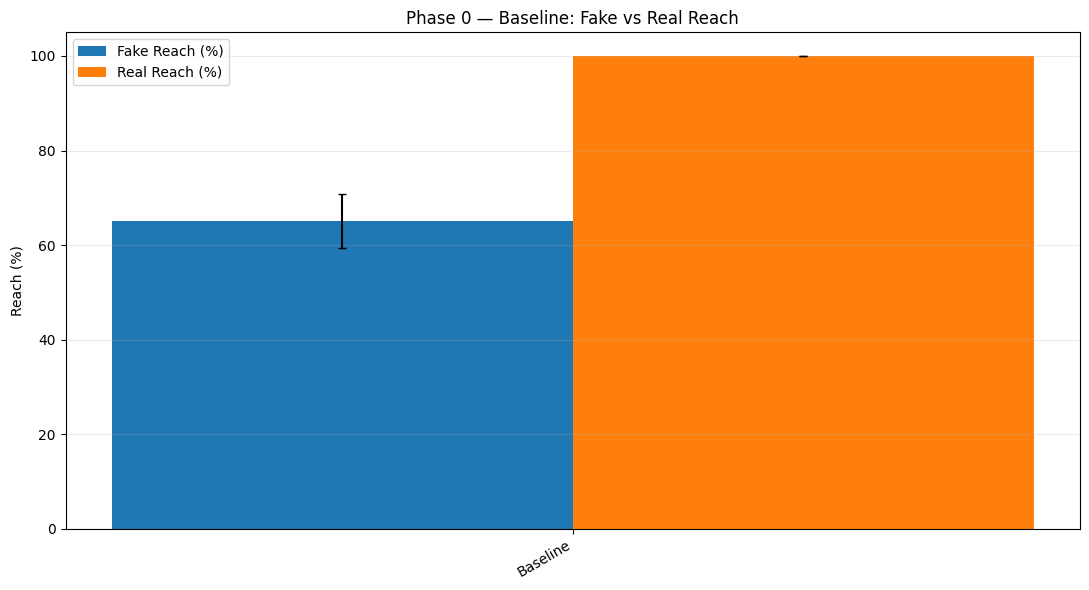

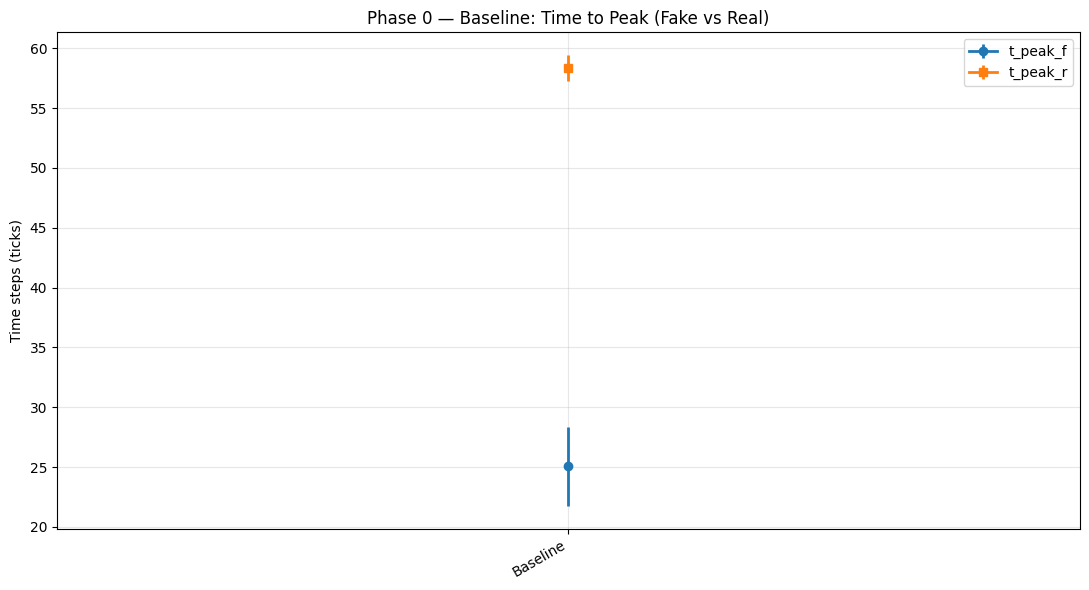

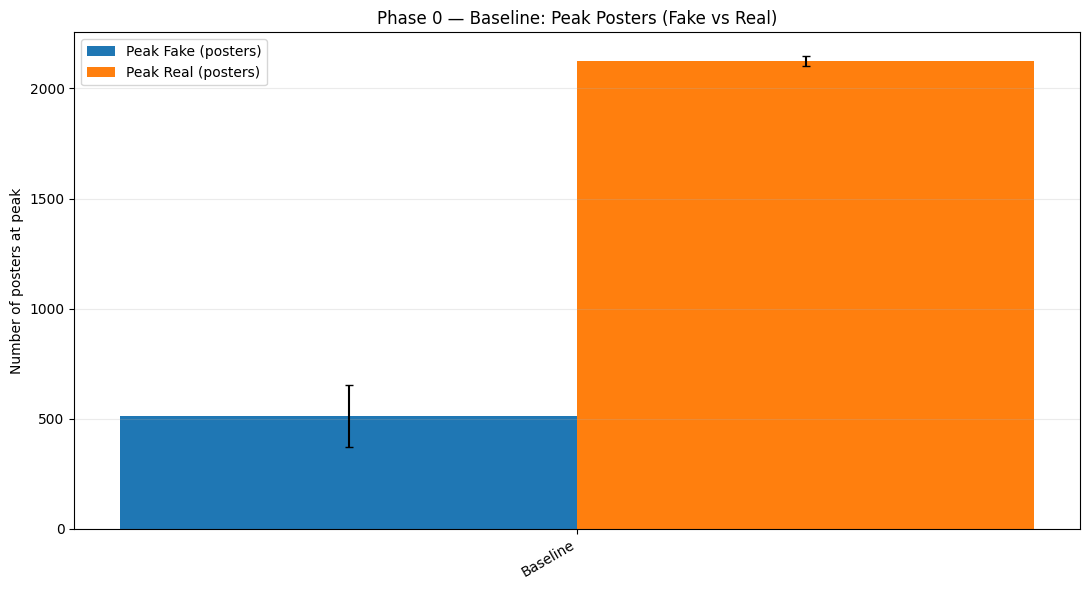

In [8]:
# --- Cell 3: PHASE 0 — Baseline only (randomness + decay, no M1–M5) ---

import pandas as pd
import numpy as np

# Output folder for Phase 0 figures
FIGDIR0 = PROJECT_ROOT / "data" / "figures" / "phase0_revise"
FIGDIR0.mkdir(parents=True, exist_ok=True)

# === NEW: use Option 1 loader instead of prefix search ===
try:
    stats0 = summarise_condition_for_label("Baseline")
except Exception as e:
    print(f"⚠️  Could not load baseline data: {e}")
    stats0 = pd.Series(dtype=float)

# --- Summary and export ---
if stats0.empty:
    print("No Phase 0 baseline data found in your whitelisted folder:")
    print("  ", RUNS / FOLDERS.get("Baseline", "(missing)"))
else:
    # Convert Series to DataFrame
    phase0_df = pd.DataFrame([stats0])
    phase0_df["Condition"] = "Baseline"

    print("Phase 0 — Baseline summary (mean ± sd; n columns = sample counts):")
    display(phase0_df.round(3))

    # Save Excel
    excel0 = FIGDIR0 / "phase0_baseline_metrics.xlsx"
    with pd.ExcelWriter(excel0, engine="xlsxwriter") as xw:
        phase0_df.set_index("Condition").round(3).to_excel(xw, sheet_name="Phase0_Baseline")
    print(f"✔ Saved Excel → {excel0}")

    # 1️⃣ Reach
    if {"mean_reachF","std_reachF","mean_reachR","std_reachR"}.issubset(phase0_df.columns):
        plot_grouped_reach(
            phase0_df,
            "Condition",
            FIGDIR0 / "phase0_plot1_reach_grouped.png",
            "Phase 0 — Baseline: Fake vs Real Reach"
        )
    else:
        print("Reach columns missing; skipping Phase 0 Plot 1.")

    # 2️⃣ Time to peak
    if {"mean_t_peak_f","std_t_peak_f","mean_t_peak_r","std_t_peak_r"}.issubset(phase0_df.columns):
        plot_time_to_peak(
            phase0_df,
            "Condition",
            FIGDIR0 / "phase0_plot2_time_to_peak.png",
            "Phase 0 — Baseline: Time to Peak (Fake vs Real)"
        )
    else:
        print("Time-to-peak columns missing; skipping Phase 0 Plot 2.")

    # 3️⃣ Peak posters
    if {"mean_peak_f","std_peak_f","mean_peak_r","std_peak_r"}.issubset(phase0_df.columns):
        plot_peak_bars(
            phase0_df,
            "Condition",
            FIGDIR0 / "phase0_plot3_peak_posters.png",
            "Phase 0 — Baseline: Peak Posters (Fake vs Real)"
        )
    else:
        print("Peak columns missing; skipping Phase 0 Plot 3.")


✔ Saved Excel → C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase1_revise\phase1_metrics.xlsx
✔ Saved CSV   → C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase1_revise\phase1_metrics.csv


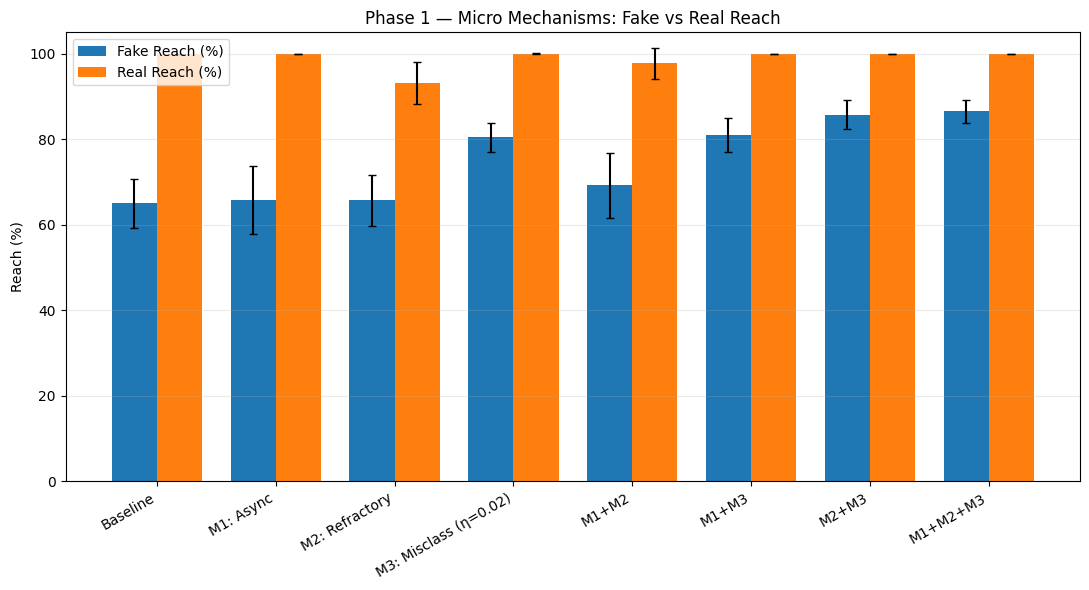

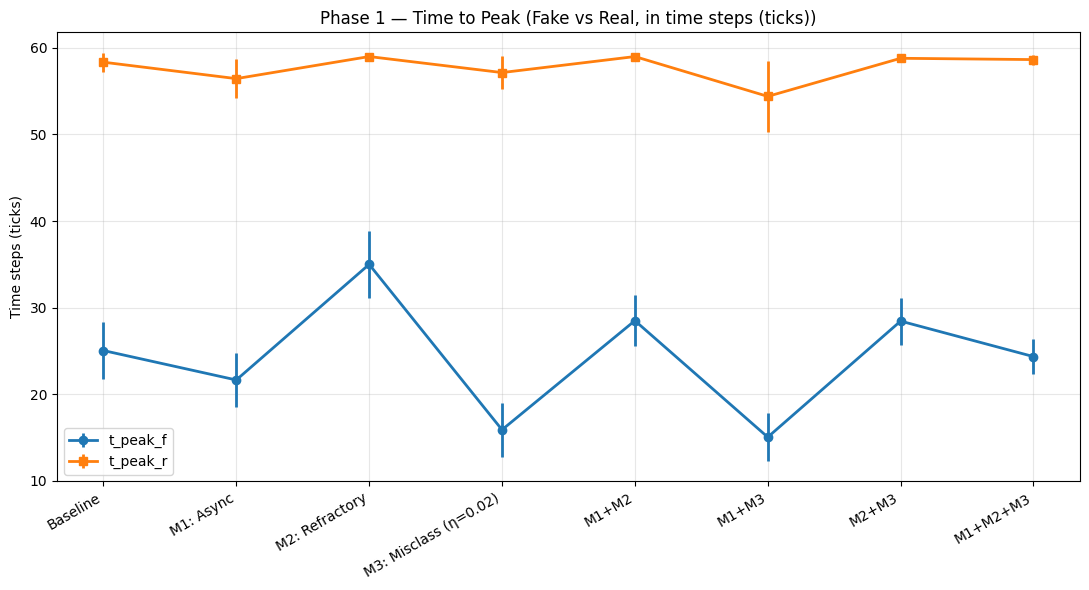

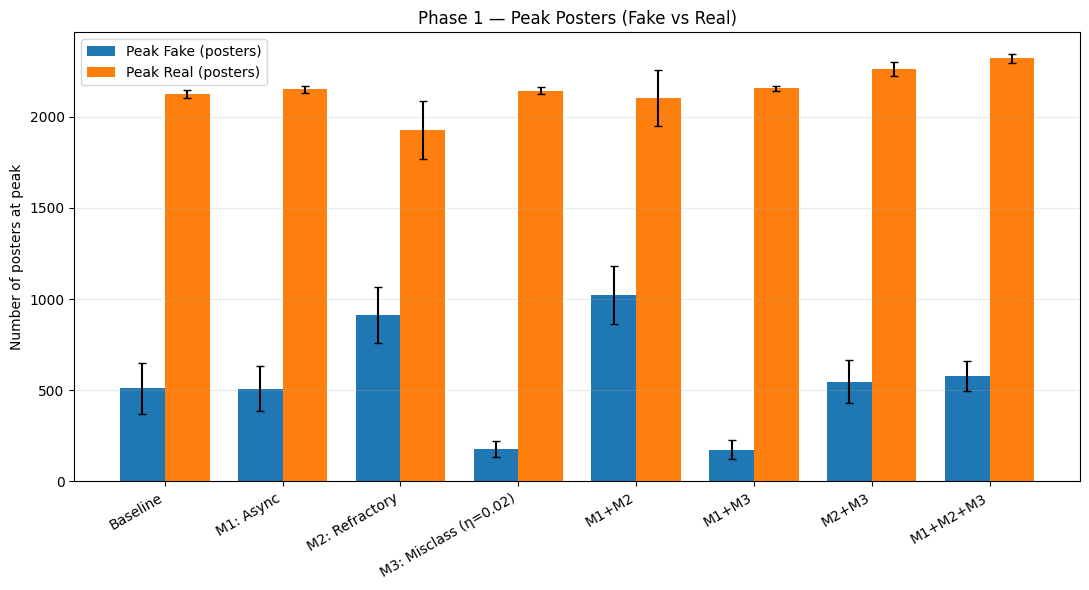

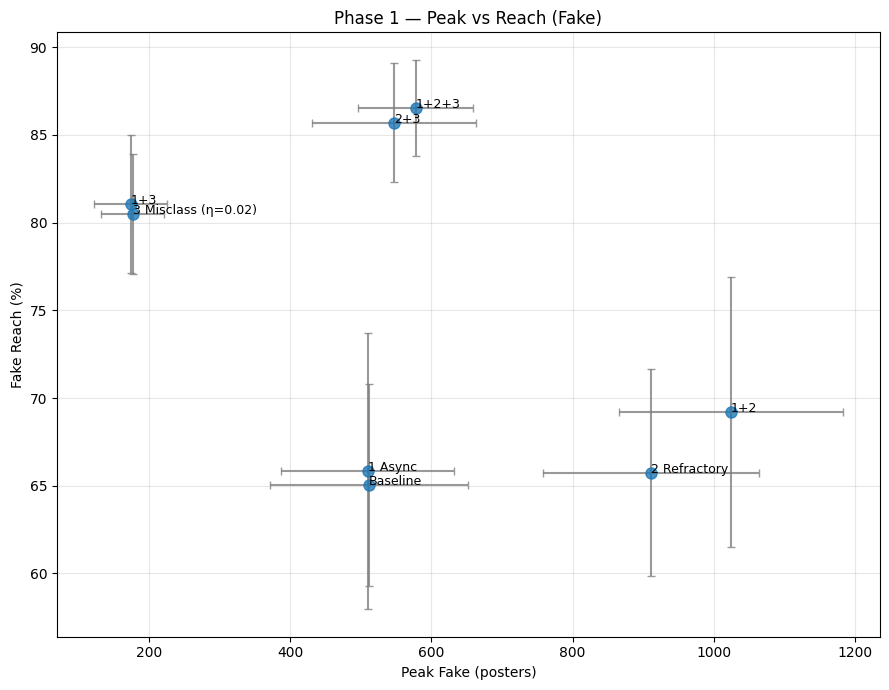

In [9]:
# --- Cell 4: PHASE 1 aggregation + outputs (Option 1, save to *_revise) ---

# Output folder for Phase 1 (revised)
FIGDIR = PROJECT_ROOT / "data" / "figures" / "phase1_revise"
FIGDIR.mkdir(parents=True, exist_ok=True)

# Display/order labels exactly as you want them to appear
P1_LABELS = [
    "Baseline",
    "M1: Async",
    "M2: Refractory",
    "M3: Misclass (η=0.02)",
    "M1+M2",
    "M1+M3",
    "M2+M3",
    "M1+M2+M3",
]

rows, errors = [], []

# Load exactly ONE whitelisted folder per label (from FOLDERS in Cell 1)
for label in P1_LABELS:
    try:
        stats = summarise_condition_for_label(label)  # Option 1 exact-folder loader from Cell 2
        if not stats.empty:
            stats["Condition"] = label
            rows.append(stats)
        else:
            errors.append(f"{label}: empty summary (no usable columns)")
    except Exception as e:
        errors.append(f"{label}: {e}")

# Soft-report any issues but proceed if we have at least some data
if errors:
    print("⚠️  Some Phase 1 conditions could not be loaded:")
    for msg in errors:
        print("   •", msg)

phase1_df = pd.DataFrame(rows)
if phase1_df.empty:
    raise RuntimeError(
        "No Phase 1 batches loaded. Check the FOLDERS mapping in Cell 1 and the loader in Cell 2."
    )

# Order rows by our label list
order_map = {label: i for i, label in enumerate(P1_LABELS)}
phase1_df["__o"] = phase1_df["Condition"].map(order_map).fillna(999)
phase1_df = phase1_df.sort_values("__o").drop(columns="__o")

# Save Excel (revised)
excel_path = FIGDIR / "phase1_metrics.xlsx"
with pd.ExcelWriter(excel_path, engine="xlsxwriter") as xw:
    phase1_df.set_index("Condition").round(3).to_excel(xw, sheet_name="Phase1_Summary")
print(f"✔ Saved Excel → {excel_path}")

# (Optional) also save a CSV for quick diffs
csv_path = FIGDIR / "phase1_metrics.csv"
phase1_df.to_csv(csv_path, index=False)
print(f"✔ Saved CSV   → {csv_path}")

# -------------------
# Plots (saved to *_revise folder)
# -------------------

# 1) Grouped reach (Fake vs Real)
if {"mean_reachF","std_reachF","mean_reachR","std_reachR"}.issubset(phase1_df.columns):
    plot_grouped_reach(
        phase1_df,
        "Condition",
        FIGDIR / "phase1_plot1_reach_grouped.png",
        "Phase 1 — Micro Mechanisms: Fake vs Real Reach"
    )
else:
    print("Reach columns missing; skipping Plot 1 (grouped reach).")

# 2) Time to peak (Fake vs Real)
if {"mean_t_peak_f","std_t_peak_f","mean_t_peak_r","std_t_peak_r"}.issubset(phase1_df.columns):
    plot_time_to_peak(
        phase1_df,
        "Condition",
        FIGDIR / "phase1_plot2_time_to_peak.png",
        "Phase 1 — Time to Peak (Fake vs Real, in time steps (ticks))"
    )
else:
    print("Time-to-peak columns missing; skipping Plot 2.")

# 3) Peaks (Fake vs Real)
if {"mean_peak_f","std_peak_f","mean_peak_r","std_peak_r"}.issubset(phase1_df.columns):
    plot_peak_bars(
        phase1_df,
        "Condition",
        FIGDIR / "phase1_plot3_peak_posters.png",
        "Phase 1 — Peak Posters (Fake vs Real)"
    )
else:
    print("Peak columns missing; skipping Plot 3.")

# 4) Scatter: Peak Fake vs Reach Fake
if {"mean_peak_f","std_peak_f","mean_reachF","std_reachF"}.issubset(phase1_df.columns):
    plot_scatter_peak_vs_reach_fake(
        phase1_df,
        "Condition",
        FIGDIR / "phase1_plot4_scatter_peak_vs_reach_fake.png",
        "Phase 1 — Peak vs Reach (Fake)"
    )
else:
    print("Need peak_f and reachF to draw Plot 4; skipping.")


✔ Saved Excel → C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase2_revise\phase2_metrics.xlsx
✔ Saved CSV   → C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase2_revise\phase2_metrics.csv


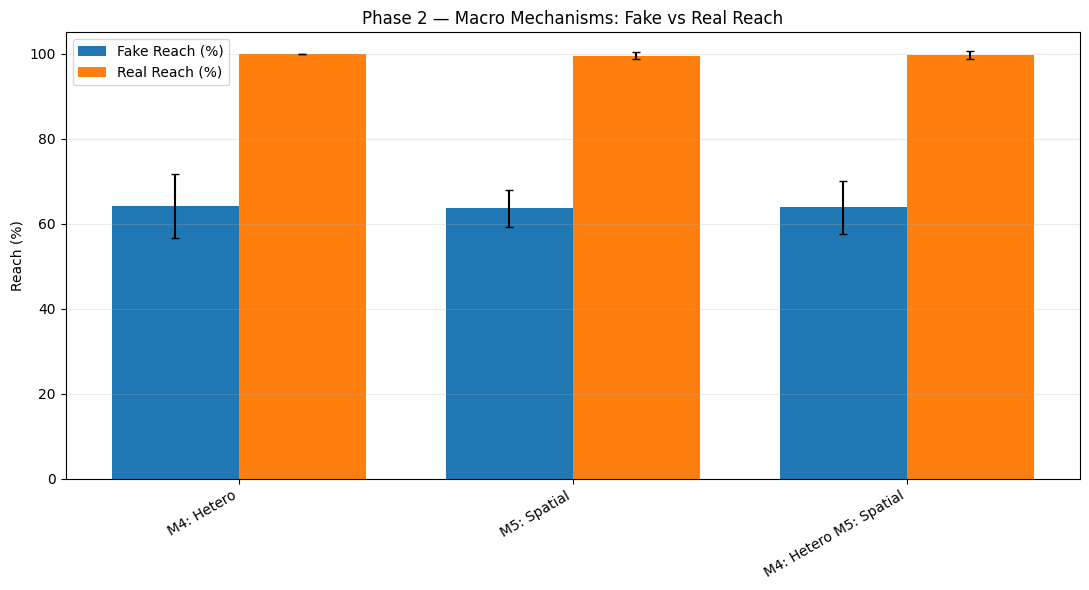

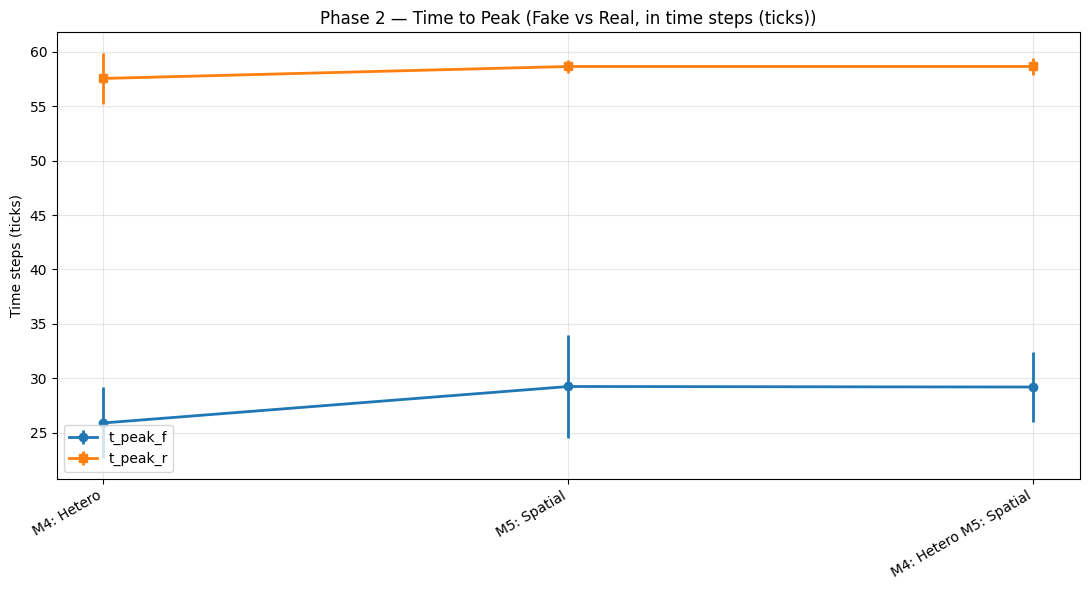

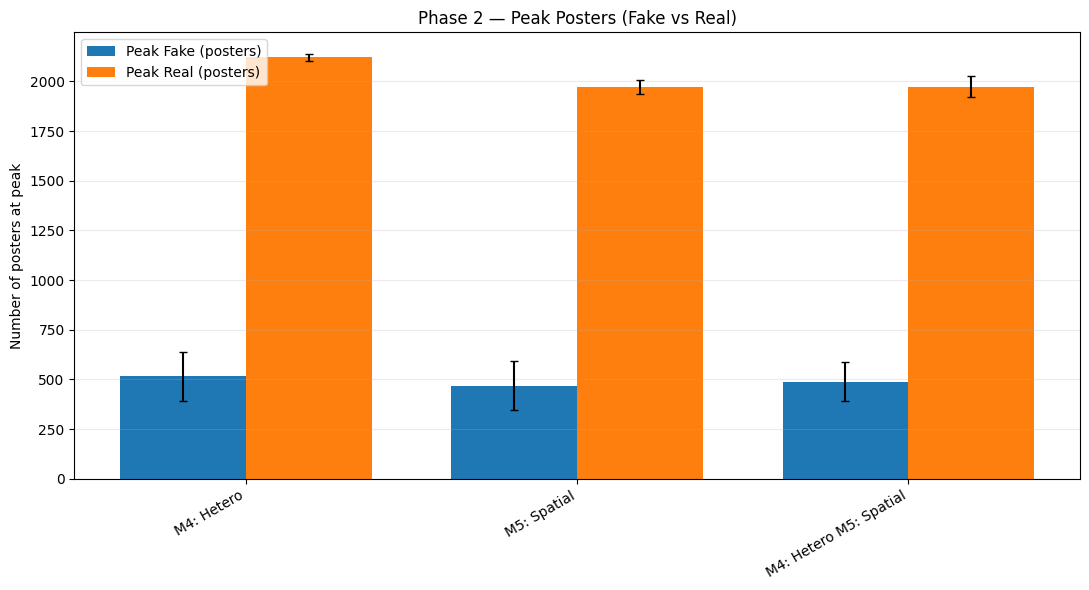

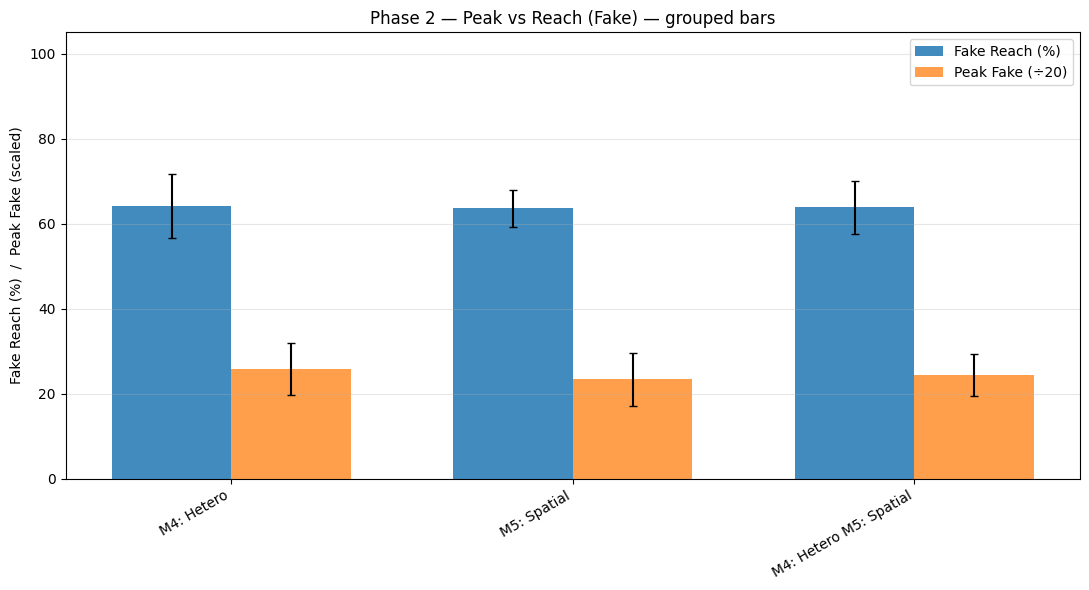

In [10]:
# --- Cell 5: PHASE 2 aggregation + outputs (Option 1, save to *_revise) ---

# Output folder for Phase 2 (revised)
FIGDIR2 = PROJECT_ROOT / "data" / "figures" / "phase2_revise"
FIGDIR2.mkdir(parents=True, exist_ok=True)

# Display/order labels exactly as you want them to appear
P2_LABELS = [
    "M4: Hetero",
    "M5: Spatial",
    "M4: Hetero M5: Spatial",
]

rows2, errors2 = [], []

# Load exactly ONE whitelisted folder per label (from FOLDERS in Cell 1)
for label in P2_LABELS:
    try:
        stats = summarise_condition_for_label(label)  # Option 1 exact-folder loader (Cell 2)
        if not stats.empty:
            stats["Condition"] = label
            rows2.append(stats)
        else:
            errors2.append(f"{label}: empty summary (no usable columns)")
    except Exception as e:
        errors2.append(f"{label}: {e}")

# Soft-report any issues but proceed if we have at least some data
if errors2:
    print("⚠️  Some Phase 2 conditions could not be loaded:")
    for msg in errors2:
        print("   •", msg)

phase2_df = pd.DataFrame(rows2)
if phase2_df.empty:
    print("No Phase 2 macro batches loaded. Check the FOLDERS mapping in Cell 1.")
else:
    # Order rows by our label list
    order_map2 = {label: i for i, label in enumerate(P2_LABELS)}
    phase2_df["__o"] = phase2_df["Condition"].map(order_map2).fillna(999)
    phase2_df = phase2_df.sort_values("__o").drop(columns="__o")

    # Save Excel (revised)
    excel2 = FIGDIR2 / "phase2_metrics.xlsx"
    with pd.ExcelWriter(excel2, engine="xlsxwriter") as xw:
        phase2_df.set_index("Condition").round(3).to_excel(xw, sheet_name="Phase2_Summary")
    print(f"✔ Saved Excel → {excel2}")

    # (Optional) also save a CSV for quick diffs
    csv2 = FIGDIR2 / "phase2_metrics.csv"
    phase2_df.to_csv(csv2, index=False)
    print(f"✔ Saved CSV   → {csv2}")

    # -------------------
    # Plots (saved to *_revise folder)
    # -------------------

    # 1) Grouped reach (Fake vs Real)
    if {"mean_reachF","std_reachF","mean_reachR","std_reachR"}.issubset(phase2_df.columns):
        plot_grouped_reach(
            phase2_df, "Condition", FIGDIR2/"phase2_plot1_reach_grouped.png",
            "Phase 2 — Macro Mechanisms: Fake vs Real Reach"
        )
    else:
        print("Reach columns missing; skipping Plot 1 for Phase 2.")

    # 2) Time to peak (Fake vs Real)
    if {"mean_t_peak_f","std_t_peak_f","mean_t_peak_r","std_t_peak_r"}.issubset(phase2_df.columns):
        plot_time_to_peak(
            phase2_df, "Condition", FIGDIR2/"phase2_plot2_time_to_peak.png",
            "Phase 2 — Time to Peak (Fake vs Real, in time steps (ticks))"
        )
    else:
        print("Time-to-peak columns missing; skipping Plot 2 for Phase 2.")

    # 3) Peaks (Fake vs Real)
    if {"mean_peak_f","std_peak_f","mean_peak_r","std_peak_r"}.issubset(phase2_df.columns):
        plot_peak_bars(
            phase2_df, "Condition", FIGDIR2/"phase2_plot3_peak_posters.png",
            "Phase 2 — Peak Posters (Fake vs Real)"
        )
    else:
        print("Peak columns missing; skipping Plot 3 for Phase 2.")

    # 4) Peak vs Reach (Fake) — grouped bars (scaled peak)
    if {"mean_peak_f","std_peak_f","mean_reachF","std_reachF"}.issubset(phase2_df.columns):
        plot_peak_vs_reach_bar(
            phase2_df, "Condition", FIGDIR2/"phase2_plot4_peak_vs_reach_fake_grouped.png",
            "Phase 2 — Peak vs Reach (Fake) — grouped bars", scale=20
        )
    else:
        print("Need peak_f and reachF to draw Plot 4; skipping for Phase 2.")


✔ Saved Excel → C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase3_revise\phase3_metrics.xlsx
✔ Saved CSV   → C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase3_revise\phase3_metrics.csv


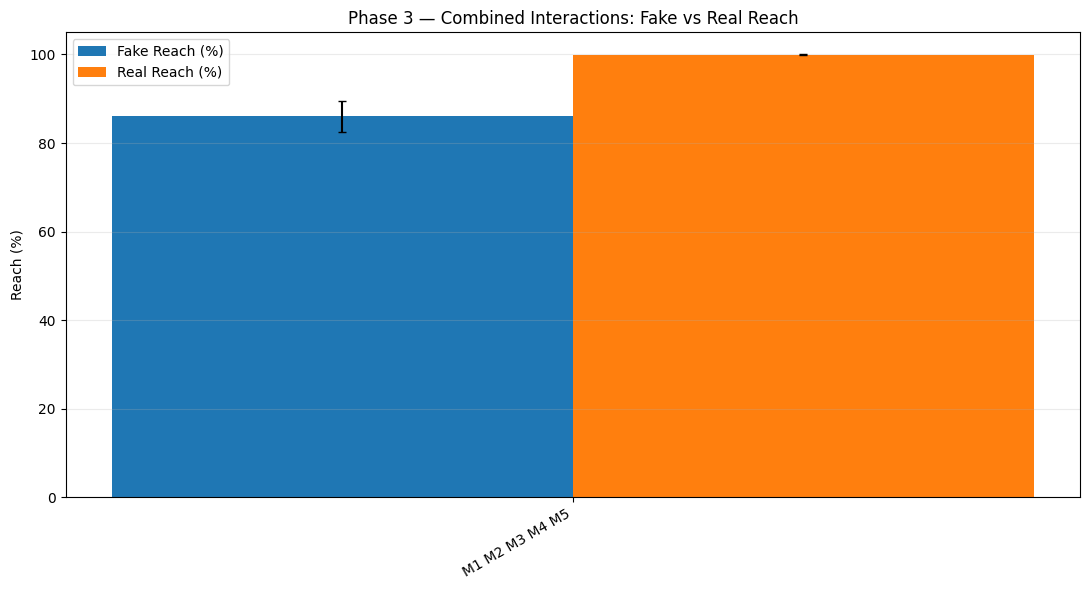

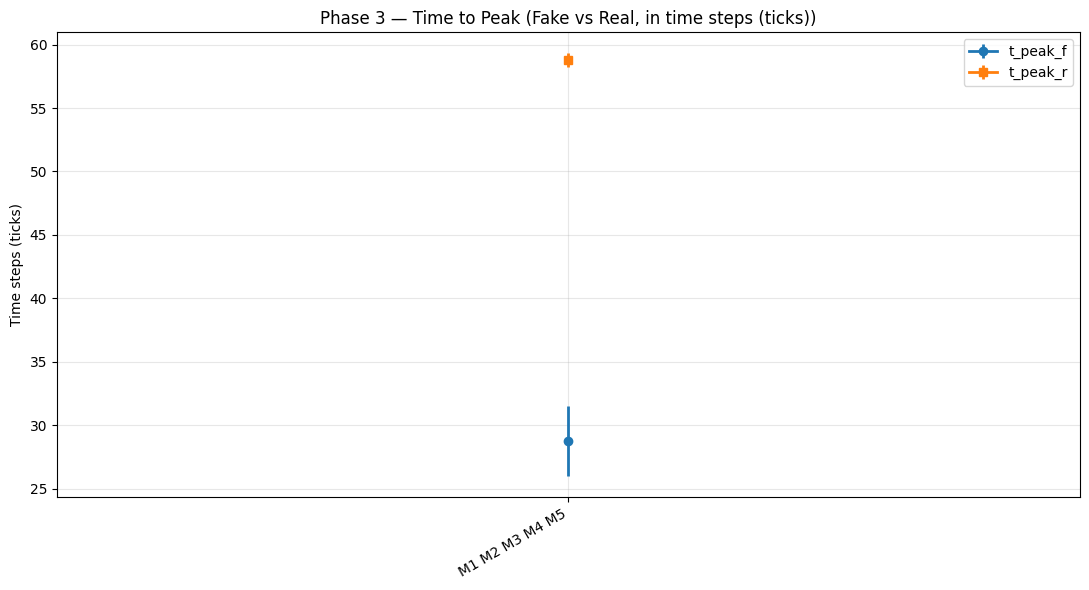

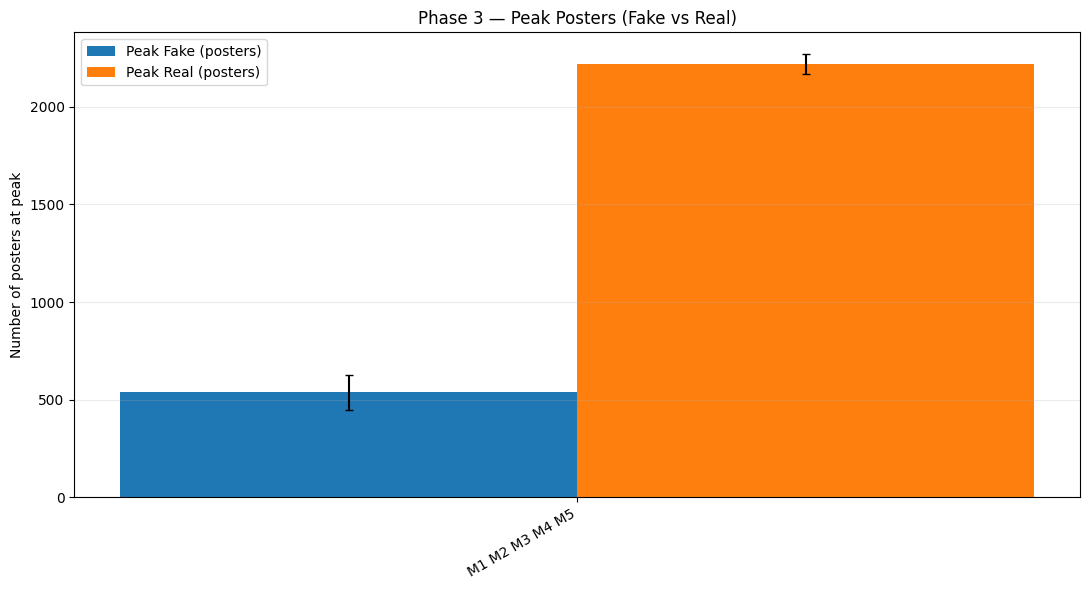

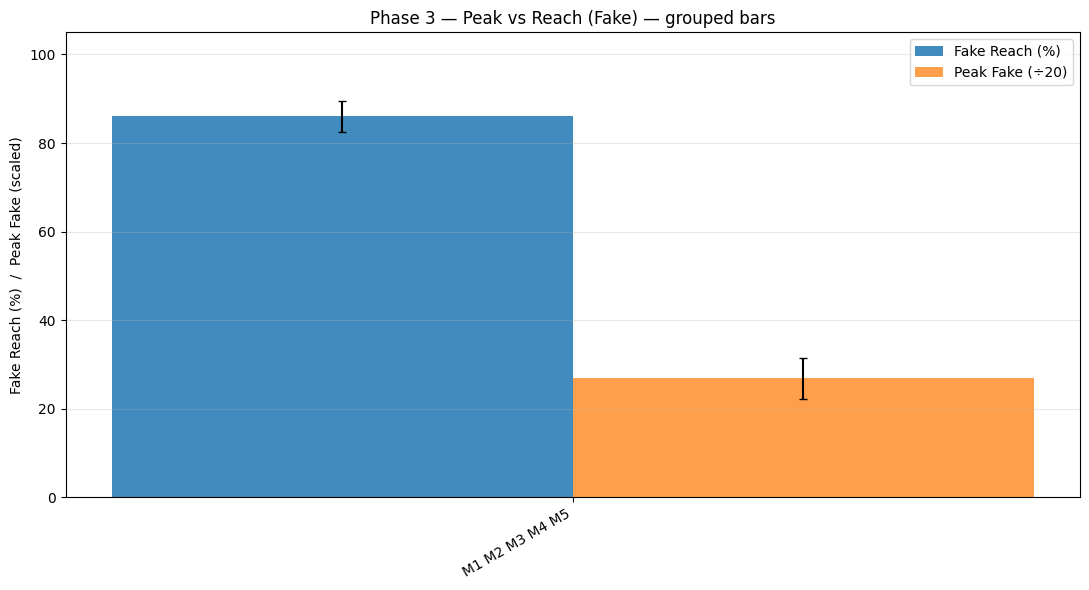

In [11]:
# --- Cell 6: PHASE 3 aggregation + outputs (Option 1, save to *_revise) ---

# Output folder for Phase 3 (revised)
FIGDIR3 = PROJECT_ROOT / "data" / "figures" / "phase3_revise"
FIGDIR3.mkdir(parents=True, exist_ok=True)

# Phase 3 labels you want to include (ordered for display)
# From your runs, you have the full combo as:
#   "M1 M2 M3 M4 M5"  -> async + refractory + misclass + hetero + spatial
P3_LABELS = [
    "M1 M2 M3 M4 M5",
]

rows3, errors3 = [], []

# Load exactly ONE whitelisted folder per label (from FOLDERS in Cell 1)
for label in P3_LABELS:
    try:
        stats = summarise_condition_for_label(label)  # Option 1 exact-folder loader (Cell 2)
        if not stats.empty:
            stats["Condition"] = label
            rows3.append(stats)
        else:
            errors3.append(f"{label}: empty summary (no usable columns)")
    except Exception as e:
        errors3.append(f"{label}: {e}")

# Soft-report any issues but proceed if we have at least some data
if errors3:
    print("⚠️  Some Phase 3 conditions could not be loaded:")
    for msg in errors3:
        print("   •", msg)

phase3_df = pd.DataFrame(rows3)
if phase3_df.empty:
    print("No Phase 3 interaction batches loaded. Check the FOLDERS mapping in Cell 1.")
else:
    # Order rows by our label list
    order_map3 = {label: i for i, label in enumerate(P3_LABELS)}
    phase3_df["__o"] = phase3_df["Condition"].map(order_map3).fillna(999)
    phase3_df = phase3_df.sort_values("__o").drop(columns="__o")

    # Save Excel (revised)
    excel3 = FIGDIR3 / "phase3_metrics.xlsx"
    with pd.ExcelWriter(excel3, engine="xlsxwriter") as xw:
        phase3_df.set_index("Condition").round(3).to_excel(xw, sheet_name="Phase3_Summary")
    print(f"✔ Saved Excel → {excel3}")

    # (Optional) also save a CSV for quick diffs
    csv3 = FIGDIR3 / "phase3_metrics.csv"
    phase3_df.to_csv(csv3, index=False)
    print(f"✔ Saved CSV   → {csv3}")

    # -------------------
    # Plots (saved to *_revise folder)
    # -------------------

    # 1) Grouped reach (Fake vs Real)
    if {"mean_reachF","std_reachF","mean_reachR","std_reachR"}.issubset(phase3_df.columns):
        plot_grouped_reach(
            phase3_df, "Condition", FIGDIR3/"phase3_plot1_reach_grouped.png",
            "Phase 3 — Combined Interactions: Fake vs Real Reach"
        )
    else:
        print("Reach columns missing; skipping Plot 1 for Phase 3.")

    # 2) Time to peak (Fake vs Real)
    if {"mean_t_peak_f","std_t_peak_f","mean_t_peak_r","std_t_peak_r"}.issubset(phase3_df.columns):
        plot_time_to_peak(
            phase3_df, "Condition", FIGDIR3/"phase3_plot2_time_to_peak.png",
            "Phase 3 — Time to Peak (Fake vs Real, in time steps (ticks))"
        )
    else:
        print("Time-to-peak columns missing; skipping Plot 2 for Phase 3.")

    # 3) Peaks (Fake vs Real)
    if {"mean_peak_f","std_peak_f","mean_peak_r","std_peak_r"}.issubset(phase3_df.columns):
        plot_peak_bars(
            phase3_df, "Condition", FIGDIR3/"phase3_plot3_peak_posters.png",
            "Phase 3 — Peak Posters (Fake vs Real)"
        )
    else:
        print("Peak columns missing; skipping Plot 3 for Phase 3.")

    # 4) Peak vs Reach (Fake) — grouped bars (scaled peak)
    if {"mean_peak_f","std_peak_f","mean_reachF","std_reachF"}.issubset(phase3_df.columns):
        plot_peak_vs_reach_bar(
            phase3_df, "Condition", FIGDIR3/"phase3_plot4_peak_vs_reach_fake_grouped.png",
            "Phase 3 — Peak vs Reach (Fake) — grouped bars", scale=20
        )
    else:
        print("Need peak_f and reachF to draw Plot 4; skipping for Phase 3.")


Saved Excel → C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase3\phase3_metrics.xlsx


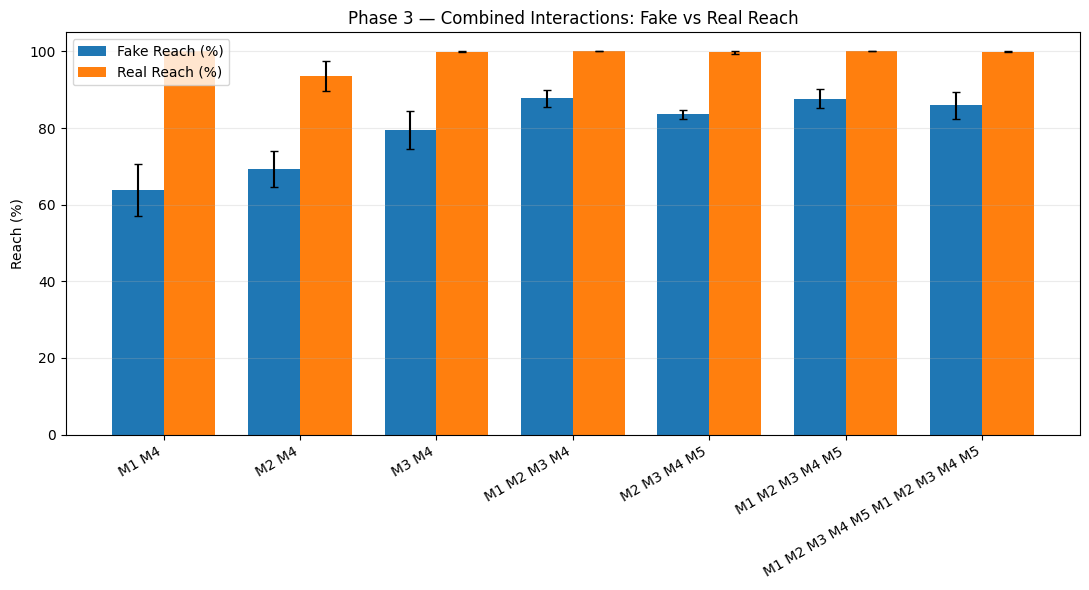

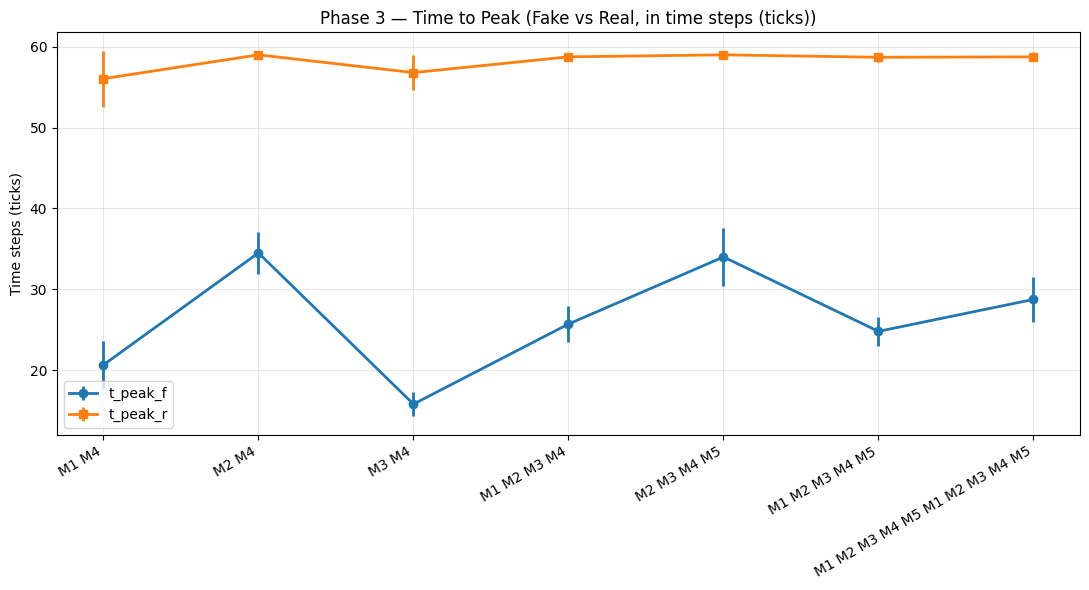

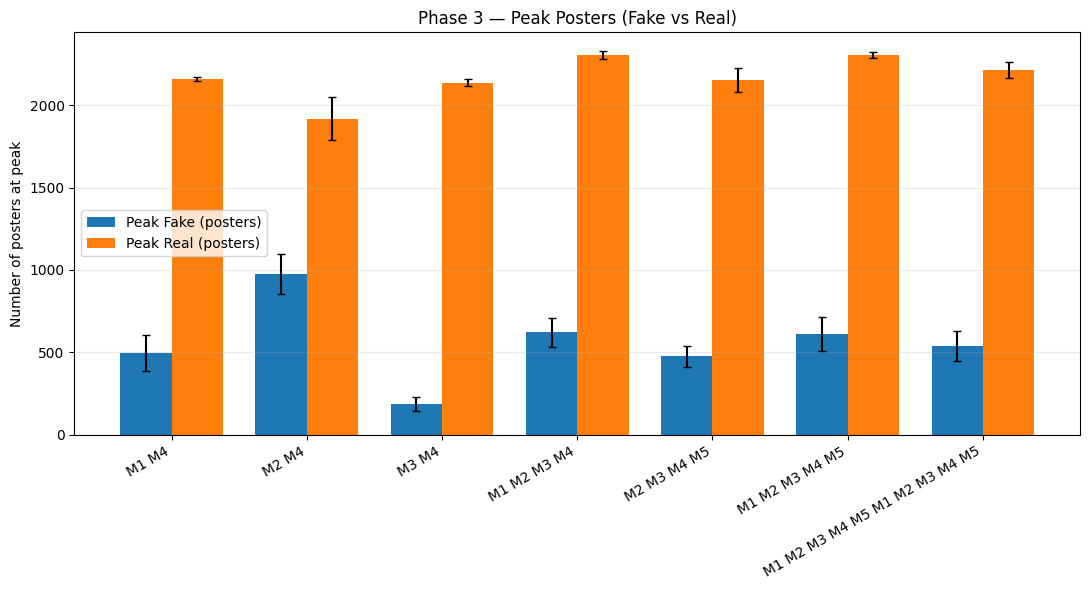

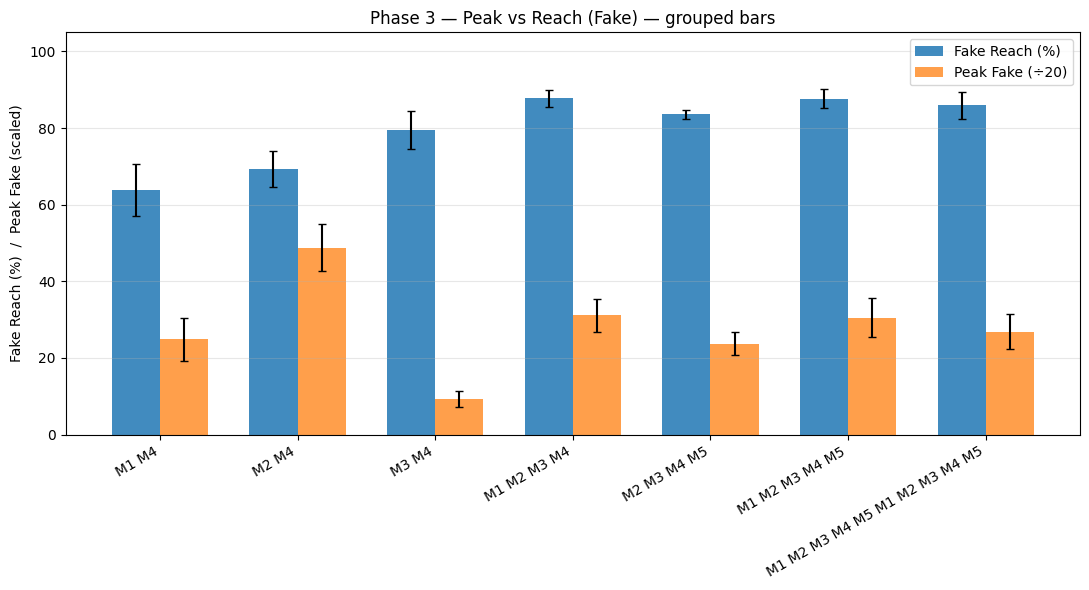